<a href="https://colab.research.google.com/github/sravanisagara2721/CodeTech-ML-Internship/blob/main/image_classification_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [ ]:
# -------------------------------------------------------
# 1. LOAD DATASET - CIFAR-10
#    10 classes: airplane, automobile, bird, cat, deer,
#                dog, frog, horse, ship, truck
# -------------------------------------------------------
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("\nTraining images shape :", X_train.shape)
print("Testing images shape  :", X_test.shape)
print("Pixel value range     :", X_train.min(), "-", X_train.max())


Training images shape : (50000, 32, 32, 3)
Testing images shape  : (10000, 32, 32, 3)
Pixel value range     : 0 - 255


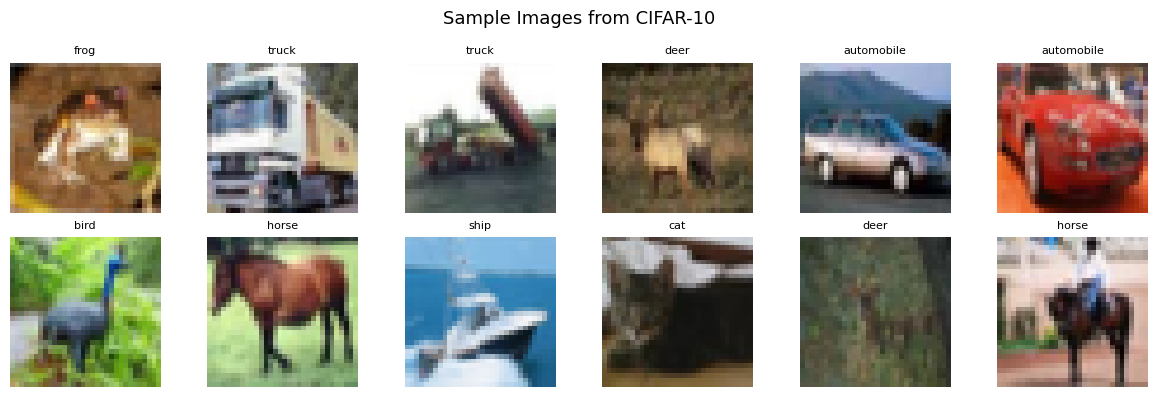

In [ ]:
# -------------------------------------------------------
# 2. VISUALIZE SAMPLE IMAGES
# -------------------------------------------------------
plt.figure(figsize=(12, 4))
for i in range(12):
    plt.subplot(2, 6, i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]], fontsize=8)
    plt.axis('off')
plt.suptitle('Sample Images from CIFAR-10', fontsize=13)
plt.tight_layout()
plt.show()

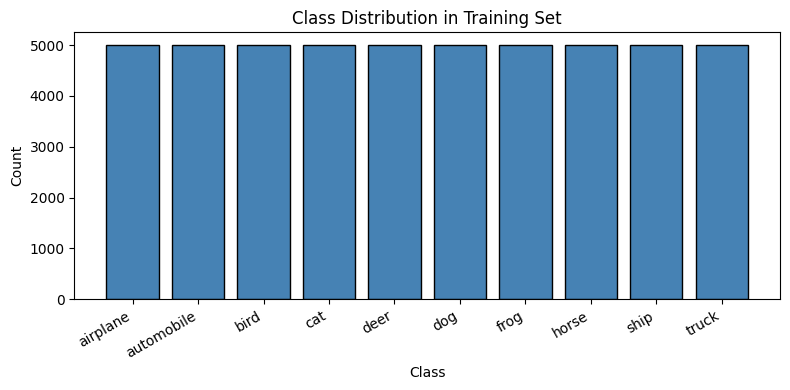

In [ ]:
# -------------------------------------------------------
# 3. CLASS DISTRIBUTION
# -------------------------------------------------------
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(8, 4))
plt.bar(class_names, counts, color='steelblue', edgecolor='black')
plt.title('Class Distribution in Training Set')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# -------------------------------------------------------
# 4. PREPROCESSING
#    - Normalize pixel values from 0-255 to 0-1
#    - One-hot encode labels
# -------------------------------------------------------
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

y_train_enc = to_categorical(y_train, num_classes=10)
y_test_enc  = to_categorical(y_test,  num_classes=10)

print("\nAfter preprocessing:")
print("X_train range:", X_train.min(), "-", X_train.max())
print("y_train_enc shape:", y_train_enc.shape)



After preprocessing:
X_train range: 0.0 - 1.0
y_train_enc shape: (50000, 10)


In [ ]:
# 5. BUILD CNN MODEL
#    Architecture:
#    Conv2D -> MaxPool -> Conv2D -> MaxPool ->
#    Conv2D -> MaxPool -> Flatten -> Dense -> Dropout -> Output
# -------------------------------------------------------
model = models.Sequential([

    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                  input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
     # Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Fully connected layers
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')   # 10 output classes
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668,458 (2.55 MB)

 Trainable params: 667,498 (2.55 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# -------------------------------------------------------
# 6. COMPILE MODEL
# -------------------------------------------------------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# -------------------------------------------------------
# 7. DATA AUGMENTATION
#    Helps model generalize better by flipping/shifting images
# -------------------------------------------------------
datagen = keras.preprocessing.image.ImageDataGenerator(
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)
datagen.fit(X_train)


In [ ]:
# -------------------------------------------------------
# 8. TRAIN MODEL
# -------------------------------------------------------
early_stop = EarlyStopping(monitor='val_loss', patience=5,
                            restore_best_weights=True)

print("\nTraining started... (this may take a few minutes in Colab)")

history = model.fit(
    datagen.flow(X_train, y_train_enc, batch_size=64),
    epochs=30,
    validation_data=(X_test, y_test_enc),
    callbacks=[early_stop],
    verbose=1
)

print("\nTraining complete!")


Training started... (this may take a few minutes in Colab)
Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 419s 529ms/step - accuracy: 0.3906 - loss: 1.7897 - val_accuracy: 0.4889 - val_loss: 1.4450
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 374s 478ms/step - accuracy: 0.5476 - loss: 1.2586 - val_accuracy: 0.5102 - val_loss: 1.4780
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 367s 469ms/step - accuracy: 0.6205 - loss: 1.0701 - val_accuracy: 0.5814 - val_loss: 1.2799
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 366s 468ms/step - accuracy: 0.6625 - loss: 0.9638 - val_accuracy: 0.6581 - val_loss: 1.0248
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 368s 471ms/step - accuracy: 0.6845 - loss: 0.9031 - val_accuracy: 0.7320 - val_loss: 0.7767
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 368s 471ms/step - accuracy: 0.7073 - loss: 0.8429 - val_accuracy: 0.7360 - val_loss: 0.7701
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 370s 473ms/step - accuracy: 0.7162 - loss: 0.8170 - val_accuracy: 0.7331 - val_loss: 0.7586
Epoch 8/30
782/7

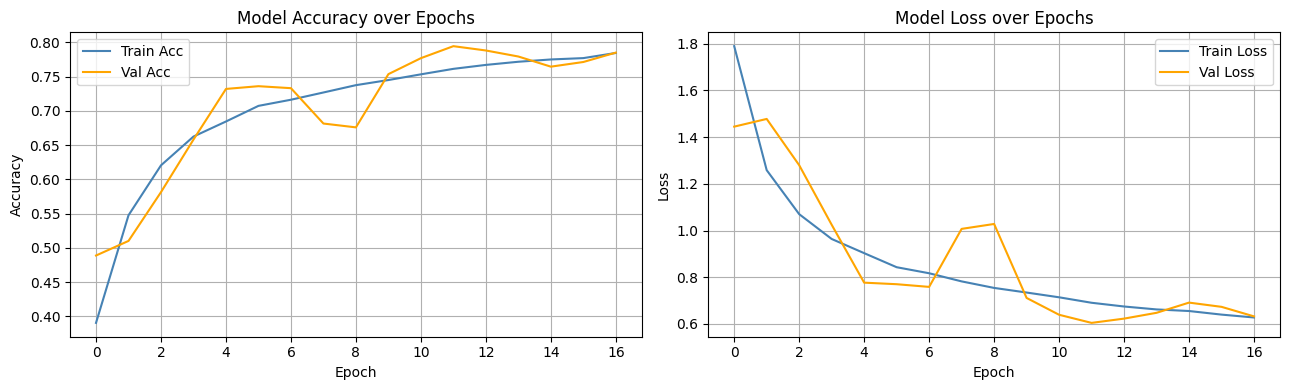

In [ ]:
# -------------------------------------------------------
# 9. PLOT TRAINING HISTORY
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# accuracy plot
axes[0].plot(history.history['accuracy'],     label='Train Acc',  color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val Acc',    color='orange')
axes[0].set_title('Model Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)
# loss plot
axes[1].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='orange')
axes[1].set_title('Model Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# -------------------------------------------------------
# 10. EVALUATE ON TEST SET
# -------------------------------------------------------
test_loss, test_acc = model.evaluate(X_test, y_test_enc, verbose=0)
print(f"\nTest Accuracy : {test_acc * 100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")



Test Accuracy : 79.44%
Test Loss     : 0.6044


313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step


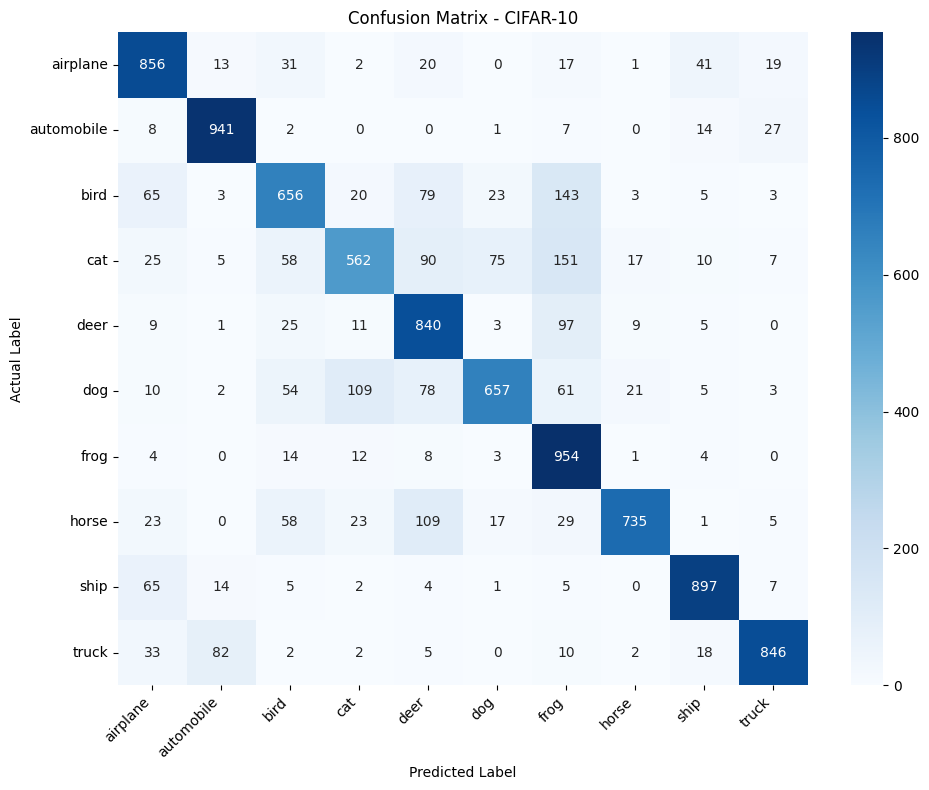

In [ ]:
# -------------------------------------------------------
# 11. CONFUSION MATRIX
# -------------------------------------------------------
y_pred_prob = model.predict(X_test)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = y_test.flatten()

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix - CIFAR-10')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# -------------------------------------------------------
# 12. CLASSIFICATION REPORT
# -------------------------------------------------------
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))



Classification Report:

              precision    recall  f1-score   support

    airplane       0.78      0.86      0.82      1000
  automobile       0.89      0.94      0.91      1000
        bird       0.72      0.66      0.69      1000
         cat       0.76      0.56      0.64      1000
        deer       0.68      0.84      0.75      1000
         dog       0.84      0.66      0.74      1000
        frog       0.65      0.95      0.77      1000
       horse       0.93      0.73      0.82      1000
        ship       0.90      0.90      0.90      1000
       truck       0.92      0.85      0.88      1000

    accuracy                           0.79     10000
   macro avg       0.81      0.79      0.79     10000
weighted avg       0.81      0.79      0.79     10000



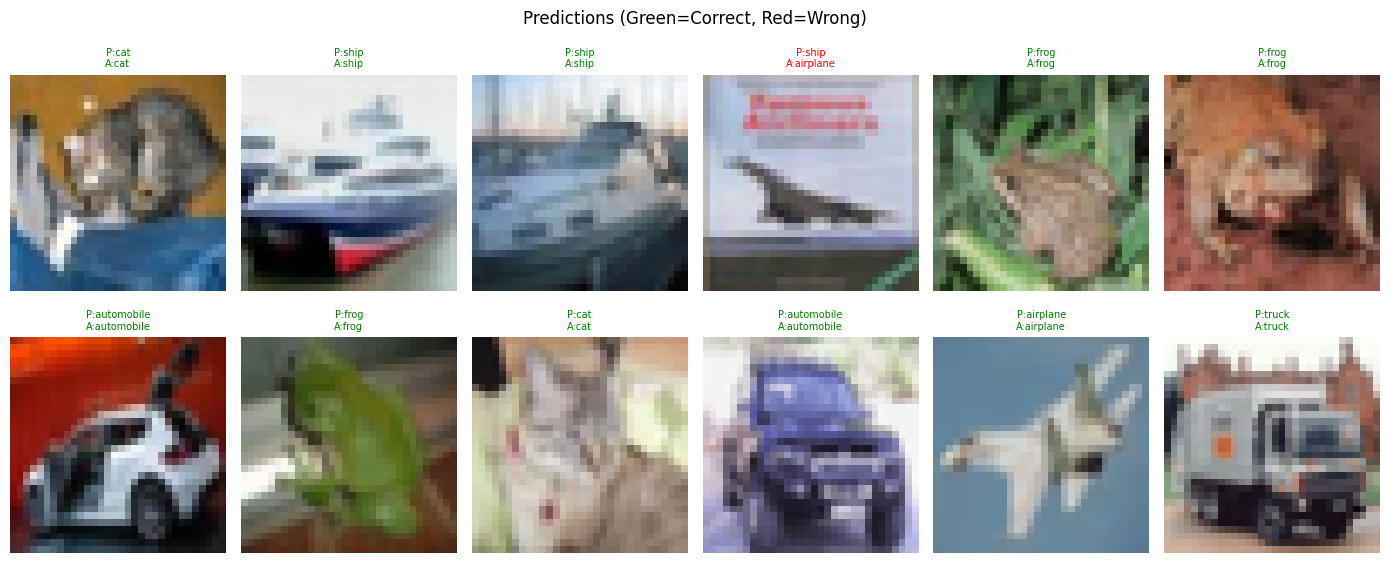

In [ ]:
# -------------------------------------------------------
# 13. VISUALIZE PREDICTIONS
# -------------------------------------------------------
plt.figure(figsize=(14, 6))
for i in range(12):
    plt.subplot(2, 6, i+1)
    plt.imshow(X_test[i])
    pred  = class_names[y_pred[i]]
    actual = class_names[y_true[i]]
    color = 'green' if pred == actual else 'red'
    plt.title(f"P:{pred}\nA:{actual}", fontsize=7, color=color)
    plt.axis('off')
plt.suptitle('Predictions (Green=Correct, Red=Wrong)', fontsize=12)
plt.tight_layout()
plt.show()

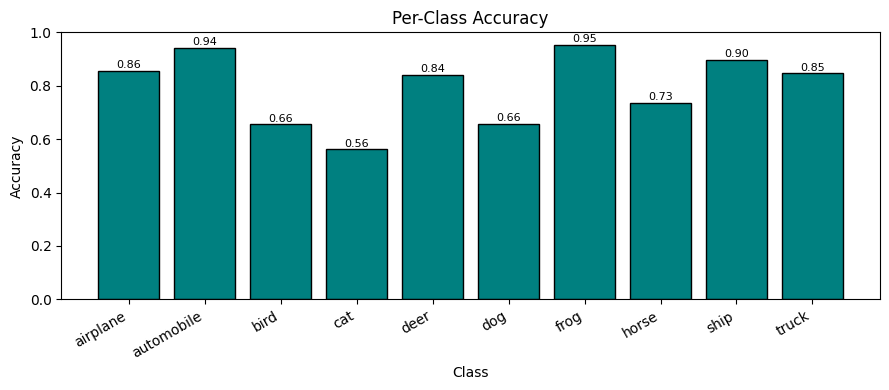

In [ ]:
# -------------------------------------------------------
# 14. PER-CLASS ACCURACY
# -------------------------------------------------------
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(9, 4))
plt.bar(class_names, per_class_acc, color='teal', edgecolor='black')
plt.title('Per-Class Accuracy')
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=30, ha='right')
for i, v in enumerate(per_class_acc):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=8)
plt.tight_layout()
plt.show()